# DNN — NinaPro DB7

## All 22 subjects | labels 13–29 | one independent DNN per subject

This notebook uses **EMG + accelerometer (ACC)** with a strict leakage-safe pipeline. For every subject and gesture, the six complete repetitions are assigned first (4 train, 1 validation, 1 test). Only after assignment is EMG filtered and the matching ACC interval resampled **inside that repetition only**. Overlapping windows are then created, features are extracted, and RobustScaler is fitted only on the training repetitions.


## Cell 1 — Imports

In [1]:
import os, gc, time, json, warnings, random, re
from pathlib import Path
import numpy as np
import pandas as pd

from scipy import io
from scipy.signal import (
    resample_poly, butter, sosfiltfilt, iirnotch, filtfilt
)
from scipy.stats import skew, kurtosis
from math import gcd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print('Imports done.')


Imports done.


## Cell 2 — Configuration

In [2]:
def _find_kaggle_input() -> Path:
    base = Path('/kaggle/input')
    if not base.exists():
        return Path('/kaggle/input/ninapro-db7/Dataset')

    def _has_subjects(p):
        return p.is_dir() and any(
            c.is_dir() and c.name.lower().startswith('subject_')
            for c in p.iterdir()
        )

    def _search(root, depth=0):
        if depth > 5:
            return None
        if _has_subjects(root):
            return root
        try:
            for child in sorted(root.iterdir()):
                if child.is_dir():
                    result = _search(child, depth + 1)
                    if result is not None:
                        return result
        except PermissionError:
            pass
        return None

    result = _search(base)
    return result if result else Path('/kaggle/input/ninapro-db7/Dataset')


class Config:
    # Paths
    KAGGLE_INPUT   = _find_kaggle_input()
    KAGGLE_WORKING = (Path('/kaggle/working') if Path('/kaggle').exists()
                      else Path.cwd() / 'dnn_loso_working')
    RUN_TAG        = 'v2_dnn_subject_specific_r4v1t1_fair'
    CKPT_DIR       = KAGGLE_WORKING / f'ckpts_{RUN_TAG}'
    DATA_CACHE_DIR = KAGGLE_WORKING / 'continuous_cache_dnn_subject_specific_v2'
    FEATURE_CACHE_DIR = KAGGLE_WORKING / f'feature_cache_{RUN_TAG}'
    PLOT_DIR       = KAGGLE_WORKING / f'plots_{RUN_TAG}'
    RESULTS_DIR    = KAGGLE_WORKING / f'results_{RUN_TAG}'

    # Population and target labels
    INTACT_SUBJECTS  = list(range(1, 21))
    AMPUTEE_SUBJECTS = [21, 22]
    SUBJECTS         = list(range(1, 23))  # all 22 DB7 subjects
    # Use e.g. [1, 2] for a quick smoke test; use all subjects for final results.
    RUN_SUBJECTS     = SUBJECTS.copy()
    PLOT_EACH_SUBJECT = False
    # Within-subject repetition protocol. DB7 uses six repetitions per gesture.
    REPS_PER_GESTURE = 6
    TRAIN_REPS = 4
    VAL_REPS = 1
    TEST_REPS = 1

    # Labels 13..29 span E1 and E2, so both files are loaded for each subject.
    EXERCISE_NAME    = 'labels13_29'
    EXERCISE_IDS     = (1, 2)

    # Dataset
    EMG_FS       = 2000
    ACC_FS       = 148
    TARGET_FS    = 2000
    EMG_KEY      = 'emg'
    ACC_KEY      = 'acc'
    LBL_KEY      = 'restimulus'
    GESTURE_MIN  = 13
    GESTURE_MAX  = 29
    N_CLASSES    = GESTURE_MAX - GESTURE_MIN + 1
    N_EMG_CH     = 12

    # Strict multimodal experiment: EMG + ACC.
    # ACC is segmented and resampled independently inside each assigned repetition.
    USE_ACC = True

    # Signal preprocessing
    BANDPASS_LOW_HZ  = 20.0
    BANDPASS_HIGH_HZ = 450.0
    FILTER_ORDER     = 4
    NOTCH_HZ         = 50.0
    NOTCH_Q          = 30.0

    # Match the corrected GNN: 400 ms window, 100 ms stride
    WIN_MS       = 400
    STEP_MS      = 100
    TRIM_MS      = 100  # discard unstable onset/offset area of each repetition
    WIN_SAMPLES  = int(WIN_MS  * TARGET_FS / 1000)
    STEP_SAMPLES = int(STEP_MS * TARGET_FS / 1000)
    TRIM_SAMPLES = int(TRIM_MS * TARGET_FS / 1000)

    # Stable feature extraction
    MAVSLP_SEGMENTS     = 3
    AR_ORDER            = 4
    USE_FREQ_FEATURES   = False
    THRESHOLD_STD_FACTOR = 0.01
    WAMP_STD_FACTOR      = 0.05
    FEATURE_CHUNK_SIZE   = 4096

    # Training
    MIN_EPOCHS      = 20
    MAX_EPOCHS      = 150
    PATIENCE        = 15
    MIN_REFIT_EPOCHS = 10
    BATCH_SIZE      = 128
    LR              = 3e-4
    DECAY           = 1e-4
    DROPOUT         = 0.15
    LABEL_SMOOTHING = 0.0
    GRAD_CLIP       = 5.0
    NUM_WORKERS     = 2
    HIDDEN          = [256, 128]
    # Match the corrected GNN: select epoch on validation, then refit on train+validation.
    REFIT_ON_TRAIN_PLUS_VAL = True

    # Prevent reuse of older single-exercise caches.
    CACHE_VERSION = 'v7_dnn_subject_specific_raw_per_file_emg_acc'
    FEATURE_CACHE_VERSION = 'v3_dnn_subject_specific_emg_acc_rep_local'

    # Reproducibility
    SEED   = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)

for directory in [
    Config.CKPT_DIR, Config.DATA_CACHE_DIR, Config.FEATURE_CACHE_DIR,
    Config.PLOT_DIR, Config.RESULTS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print(f'Device             : {Config.DEVICE}')
print(f'Population         : all DB7 subjects {Config.SUBJECTS}')
print(f'Subject models     : {Config.RUN_SUBJECTS}')
print('Exercise files      : E1 + E2')
print(f'Input modality     : {"EMG+ACC" if Config.USE_ACC else "EMG only"}')
print('Leakage control    : split repetitions before EMG filtering / ACC resampling')
print(f'Window / step      : {Config.WIN_MS} / {Config.STEP_MS} ms')
print(f'Boundary trim      : {Config.TRIM_MS} ms per side')
print(f'Gestures           : {Config.GESTURE_MIN}–{Config.GESTURE_MAX} ({Config.N_CLASSES} classes)')
print(f'LR / decay         : {Config.LR} / {Config.DECAY}')
print(f'Dropout            : {Config.DROPOUT}')
print(f'DNN layers         : {Config.HIDDEN}')
print(f'Within split       : {Config.TRAIN_REPS} train + {Config.VAL_REPS} val + {Config.TEST_REPS} test repetitions')
print(f'Refit train+val    : {Config.REFIT_ON_TRAIN_PLUS_VAL}')

assert Config.USE_ACC is True


Device             : cuda
Population         : all DB7 subjects [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Subject models     : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Exercise files      : E1 + E2
Input modality     : EMG+ACC
Leakage control    : split repetitions before EMG filtering / ACC resampling
Window / step      : 400 / 100 ms
Boundary trim      : 100 ms per side
Gestures           : 13–29 (17 classes)
LR / decay         : 0.0003 / 0.0001
Dropout            : 0.15
DNN layers         : [256, 128]
Within split       : 4 train + 1 val + 1 test repetitions
Refit train+val    : True


## Cell 3 — Raw EMG + ACC Loading and Repetition-Local Preprocessing

No filtering or ACC resampling is performed while the full recording is intact. The complete gesture repetition is assigned to train/validation/test first; then EMG filtering and ACC resampling are performed only inside that repetition.


In [3]:
class RawEMGACCPreprocessor:
    """
    Load RAW EMG, RAW ACC and EMG-aligned labels from one NinaPro file.

    No filtering, resampling, label masking, feature extraction or windowing
    is performed here.
    """

    @staticmethod
    def _find_key(data, candidates):
        for candidate in candidates:
            for key in data:
                if key.lower() == candidate.lower():
                    return key
        return None

    @staticmethod
    def _time_major(array, expected_channels=None, name='signal'):
        array = np.asarray(array)

        if array.ndim == 1:
            array = array[:, None]
        if array.ndim != 2:
            raise RuntimeError(
                f'{name}: expected a 2-D array, got {array.shape}.'
            )

        if expected_channels is not None:
            if array.shape[1] == expected_channels:
                return array
            if array.shape[0] == expected_channels:
                return array.T
            raise RuntimeError(
                f'{name}: neither dimension matches expected '
                f'{expected_channels} channels: {array.shape}.'
            )

        # ACC: time dimension should be much larger than the sensor-channel dimension.
        if array.shape[0] < array.shape[1] and array.shape[0] <= 128:
            array = array.T

        return array

    def apply(self, mat_path: Path):
        data = io.loadmat(str(mat_path))

        emg_key = self._find_key(data, [Config.EMG_KEY])
        acc_key = self._find_key(data, [Config.ACC_KEY])
        lbl_key = self._find_key(
            data,
            [Config.LBL_KEY, 'stimulus', 'label', 'labels'],
        )

        if emg_key is None:
            raise KeyError(f'No EMG key in {mat_path.name}.')
        if acc_key is None:
            raise KeyError(
                f'No ACC key in {mat_path.name}; '
                'this notebook requires EMG + ACC.'
            )
        if lbl_key is None:
            raise KeyError(f'No label key in {mat_path.name}.')

        emg = self._time_major(
            data[emg_key],
            expected_channels=Config.N_EMG_CH,
            name=f'{mat_path.name} EMG',
        ).astype(np.float32)

        acc = self._time_major(
            data[acc_key],
            expected_channels=None,
            name=f'{mat_path.name} ACC',
        ).astype(np.float32)

        labels = np.asarray(
            data[lbl_key]
        ).reshape(-1).astype(np.int32)

        # restimulus is aligned to the EMG time base.
        n = min(len(emg), len(labels))
        emg = emg[:n]
        labels = labels[:n]

        if len(acc) < 2:
            raise RuntimeError(
                f'{mat_path.name}: ACC has only {len(acc)} samples.'
            )

        return emg, acc, labels


class RepetitionEMGFilter:
    """
    Zero-phase EMG filtering applied to ONE complete repetition only.

    Because filtering happens after the split, sosfiltfilt/filtfilt cannot
    read samples from a repetition assigned to another split.
    """

    def __init__(self):
        nyquist = Config.EMG_FS / 2.0
        self.sos = butter(
            Config.FILTER_ORDER,
            [
                Config.BANDPASS_LOW_HZ / nyquist,
                Config.BANDPASS_HIGH_HZ / nyquist,
            ],
            btype='bandpass',
            output='sos',
        )
        self.b_notch, self.a_notch = iirnotch(
            Config.NOTCH_HZ / nyquist,
            Config.NOTCH_Q,
        )

    def apply(self, repetition_emg: np.ndarray) -> np.ndarray:
        repetition_emg = np.asarray(
            repetition_emg,
            dtype=np.float32,
        )

        if repetition_emg.ndim != 2:
            raise ValueError(
                f'Expected (time,channels), got {repetition_emg.shape}.'
            )
        if len(repetition_emg) < 64:
            raise RuntimeError(
                f'EMG repetition unexpectedly short: '
                f'{len(repetition_emg)} samples.'
            )

        filtered = sosfiltfilt(
            self.sos,
            repetition_emg,
            axis=0,
        )
        filtered = filtfilt(
            self.b_notch,
            self.a_notch,
            filtered,
            axis=0,
        )
        return filtered.astype(np.float32)


class RepetitionACCResampler:
    """
    Extract the ACC time interval matching ONE EMG repetition from the same
    source file, then resample only that ACC slice to the repetition's EMG length.
    """

    @staticmethod
    def extract_matching_interval(
        file_acc: np.ndarray,
        file_emg_length: int,
        emg_start: int,
        emg_end: int,
    ) -> np.ndarray:
        if not (
            0 <= emg_start < emg_end <= file_emg_length
        ):
            raise ValueError(
                f'Invalid EMG interval [{emg_start}, {emg_end}) '
                f'for file length {file_emg_length}.'
            )

        ratio = (
            len(file_acc)
            / float(file_emg_length)
        )

        # ceil avoids borrowing an ACC sample from just before the repetition.
        acc_start = int(
            np.ceil(emg_start * ratio)
        )
        acc_end = int(
            np.ceil(emg_end * ratio)
        )

        acc_start = max(
            0,
            min(
                acc_start,
                len(file_acc) - 1,
            ),
        )
        acc_end = max(
            acc_start + 1,
            min(acc_end, len(file_acc)),
        )

        acc_rep = file_acc[
            acc_start:acc_end
        ].copy()

        if len(acc_rep) < 2:
            raise RuntimeError(
                f'Mapped ACC repetition is too short: '
                f'{len(acc_rep)} samples.'
            )

        return acc_rep

    @staticmethod
    def resample_to_emg_length(
        acc_rep: np.ndarray,
        target_length: int,
    ) -> np.ndarray:
        source_length = len(acc_rep)

        divisor = gcd(
            source_length,
            target_length,
        )
        up = (
            target_length
            // divisor
        )
        down = (
            source_length
            // divisor
        )

        resampled = resample_poly(
            acc_rep,
            up,
            down,
            axis=0,
        ).astype(np.float32)

        # Any one-sample numerical length discrepancy is corrected using data
        # from this same repetition only.
        if len(resampled) > target_length:
            resampled = resampled[
                :target_length
            ]
        elif len(resampled) < target_length:
            pad_count = (
                target_length
                - len(resampled)
            )
            pad = np.repeat(
                resampled[-1:, :],
                pad_count,
                axis=0,
            )
            resampled = np.vstack(
                [resampled, pad]
            )

        if len(resampled) != target_length:
            raise RuntimeError(
                f'ACC length mismatch: '
                f'{len(resampled)} != {target_length}.'
            )

        return resampled.astype(
            np.float32
        )


print(
    'Raw EMG+ACC loader, repetition-local EMG filter '
    'and repetition-local ACC resampler defined.'
)

Raw EMG+ACC loader, repetition-local EMG filter and repetition-local ACC resampler defined.


## Cell 4 — Strict Subject Loader and Repetition Split

Each source file remains separate so an EMG repetition can be mapped to the matching raw ACC interval. Train/validation/test repetition identities are asserted disjoint before filtering, resampling, or windowing.


In [4]:
class SubjectLoader:
    def __init__(self):
        self.preprocessor = RawEMGACCPreprocessor()
        self.rep_filter = RepetitionEMGFilter()
        self.acc_resampler = RepetitionACCResampler()
        self.cache_dir = Config.DATA_CACHE_DIR

    def _ckpt_path(self, sid):
        exercise_tag = ''.join(
            f'E{exercise_id}'
            for exercise_id in Config.EXERCISE_IDS
        )
        return self.cache_dir / (
            f'RAW_FILES_S{sid:02d}_{exercise_tag}_'
            f'labels{Config.GESTURE_MIN}_{Config.GESTURE_MAX}_'
            f'emg_acc_{Config.CACHE_VERSION}.npz'
        )

    def _find_subject_dir(self, sid):
        candidates = [
            Config.KAGGLE_INPUT / f'Subject_{sid}',
            Config.KAGGLE_INPUT / f'subject_{sid}',
            Config.KAGGLE_INPUT / f'S{sid}',
            Config.KAGGLE_INPUT / f's{sid}',
        ]
        for path in candidates:
            if path.is_dir():
                return path

        for path in sorted(
            Config.KAGGLE_INPUT.iterdir()
        ):
            if (
                path.is_dir()
                and path.name.lower().endswith(
                    str(sid)
                )
            ):
                return path

        raise FileNotFoundError(
            f'Cannot find subject {sid} '
            f'under {Config.KAGGLE_INPUT}.'
        )

    @staticmethod
    def _is_exercise_file(
        path: Path,
        exercise_id: int,
    ) -> bool:
        name = path.stem.upper()
        return bool(
            re.search(
                rf'(^|_)E{exercise_id}(_|$)',
                name,
            )
        )

    def _selected_files(self, sid):
        subject_dir = (
            self._find_subject_dir(sid)
        )
        all_mat_files = (
            sorted(
                subject_dir.glob('*.mat')
            )
            or sorted(
                subject_dir.rglob('*.mat')
            )
        )

        selected = []
        for exercise_id in (
            Config.EXERCISE_IDS
        ):
            matches = [
                path
                for path in all_mat_files
                if self._is_exercise_file(
                    path,
                    exercise_id,
                )
            ]
            if not matches:
                raise FileNotFoundError(
                    f'Subject {sid}: '
                    f'missing E{exercise_id}. '
                    f'Available files: '
                    f'{[p.name for p in all_mat_files[:15]]}'
                )
            selected.extend(matches)

        return selected

    def _build_raw_file_cache(
        self,
        sid,
    ):
        mat_files = (
            self._selected_files(sid)
        )
        payload = {
            'n_files': np.array(
                len(mat_files),
                dtype=np.int64,
            ),
            'file_names_json': np.array(
                json.dumps(
                    [
                        path.name
                        for path in mat_files
                    ]
                )
            ),
        }

        acc_channel_counts = set()

        for index, mat_file in enumerate(
            mat_files
        ):
            (
                emg,
                acc,
                labels,
            ) = self.preprocessor.apply(
                mat_file
            )

            if (
                emg.shape[1]
                != Config.N_EMG_CH
            ):
                raise RuntimeError(
                    f'S{sid:02d}, '
                    f'{mat_file.name}: '
                    f'expected '
                    f'{Config.N_EMG_CH} EMG '
                    f'channels, got '
                    f'{emg.shape[1]}.'
                )

            acc_channel_counts.add(
                int(acc.shape[1])
            )

            payload[
                f'emg_{index}'
            ] = emg.astype(np.float32)
            payload[
                f'acc_{index}'
            ] = acc.astype(np.float32)
            payload[
                f'labels_{index}'
            ] = labels.astype(np.int32)

        if (
            len(acc_channel_counts)
            != 1
        ):
            raise RuntimeError(
                f'S{sid:02d}: inconsistent '
                'ACC channel counts across '
                f'E1/E2: '
                f'{sorted(acc_channel_counts)}.'
            )

        n_acc_ch = int(
            next(
                iter(
                    acc_channel_counts
                )
            )
        )
        if n_acc_ch <= 0:
            raise RuntimeError(
                f'S{sid:02d}: no ACC '
                'channels found.'
            )

        payload[
            'n_acc_ch'
        ] = np.array(
            n_acc_ch,
            dtype=np.int64,
        )

        np.savez_compressed(
            self._ckpt_path(sid),
            **payload,
        )

        return n_acc_ch

    def _raw_cache_metadata(
        self,
        sid,
    ):
        with np.load(
            self._ckpt_path(sid),
            allow_pickle=False,
        ) as data:
            return (
                int(data['n_files']),
                int(data['n_acc_ch']),
                json.loads(
                    str(
                        data[
                            'file_names_json'
                        ].item()
                    )
                ),
            )

    def _load_raw_parts(
        self,
        sid,
    ):
        parts = []

        with np.load(
            self._ckpt_path(sid),
            allow_pickle=False,
        ) as data:
            n_files = int(
                data['n_files']
            )
            n_acc_ch = int(
                data['n_acc_ch']
            )
            file_names = json.loads(
                str(
                    data[
                        'file_names_json'
                    ].item()
                )
            )

            for index in range(
                n_files
            ):
                parts.append({
                    'file_index': int(
                        index
                    ),
                    'file_name': (
                        file_names[index]
                    ),
                    'emg': data[
                        f'emg_{index}'
                    ].astype(np.float32),
                    'acc': data[
                        f'acc_{index}'
                    ].astype(np.float32),
                    'labels': data[
                        f'labels_{index}'
                    ].astype(np.int32),
                })

        return parts, n_acc_ch

    def process_all(
        self,
        subjects=None,
    ):
        subjects = (
            subjects
            or Config.SUBJECTS
        )
        available = []
        acc_counts = set()

        for sid in tqdm(
            subjects,
            desc='Loading RAW EMG+ACC subjects',
        ):
            checkpoint = (
                self._ckpt_path(sid)
            )

            if checkpoint.exists():
                (
                    n_files,
                    current_acc_ch,
                    file_names,
                ) = self._raw_cache_metadata(
                    sid
                )
                print(
                    f'  S{sid:02d}: '
                    'RAW per-file cache | '
                    f'files={n_files}, '
                    f'ACC={current_acc_ch} ch'
                )
            else:
                current_acc_ch = (
                    self._build_raw_file_cache(
                        sid
                    )
                )
                print(
                    f'  S{sid:02d}: '
                    'saved RAW per-file '
                    f'EMG+ACC cache | '
                    f'ACC={current_acc_ch} ch'
                )

            if current_acc_ch <= 0:
                raise RuntimeError(
                    f'S{sid:02d}: '
                    'ACC is required.'
                )

            acc_counts.add(
                int(current_acc_ch)
            )
            available.append(sid)

        if (
            set(available)
            != set(subjects)
        ):
            missing = sorted(
                set(subjects)
                - set(available)
            )
            raise RuntimeError(
                f'Missing subjects: {missing}'
            )

        if len(acc_counts) != 1:
            raise RuntimeError(
                'ACC channel count differs '
                'between subjects: '
                f'{sorted(acc_counts)}'
            )

        return (
            available,
            int(
                next(
                    iter(acc_counts)
                )
            ),
        )

    @staticmethod
    def _constant_label_runs(
        labels: np.ndarray,
    ):
        if len(labels) == 0:
            return

        boundaries = (
            np.flatnonzero(
                np.diff(labels) != 0
            )
            + 1
        )
        starts = np.r_[
            0,
            boundaries,
        ]
        ends = np.r_[
            boundaries,
            len(labels),
        ]

        for start, end in zip(
            starts,
            ends,
        ):
            yield (
                int(start),
                int(end),
                int(labels[start]),
            )

    @staticmethod
    def _repetition_id(
        sid,
        gesture,
        repetition_index,
    ):
        return (
            int(sid),
            int(gesture),
            int(repetition_index + 1),
        )

    @staticmethod
    def _split_repetition_indices(
        sid,
        gesture,
    ):
        rng = np.random.default_rng(
            Config.SEED
            + 1009 * int(sid)
            + 9176 * int(gesture)
        )
        perm = rng.permutation(
            Config.REPS_PER_GESTURE
        ).tolist()

        test_idx = sorted(
            perm[:Config.TEST_REPS]
        )
        val_idx = sorted(
            perm[
                Config.TEST_REPS:
                Config.TEST_REPS
                + Config.VAL_REPS
            ]
        )
        train_idx = sorted(
            perm[
                Config.TEST_REPS
                + Config.VAL_REPS:
            ]
        )

        if (
            len(train_idx)
            != Config.TRAIN_REPS
        ):
            raise RuntimeError(
                'Unexpected number of '
                'training repetitions.'
            )

        return (
            train_idx,
            val_idx,
            test_idx,
        )

    def _collect_repetitions(
        self,
        parts,
    ):
        runs_by_gesture = {
            gesture: []
            for gesture in range(
                Config.GESTURE_MIN,
                Config.GESTURE_MAX + 1,
            )
        }

        for part_index, part in enumerate(
            parts
        ):
            for (
                run_start,
                run_end,
                gesture,
            ) in self._constant_label_runs(
                part['labels']
            ):
                if (
                    gesture
                    in runs_by_gesture
                ):
                    runs_by_gesture[
                        gesture
                    ].append({
                        'part_index': int(
                            part_index
                        ),
                        'start': int(
                            run_start
                        ),
                        'end': int(
                            run_end
                        ),
                    })

        return runs_by_gesture

    def build_within_subject_splits(
        self,
        subjects,
        n_acc_ch,
    ):
        """
        Strict leakage-safe ordering:

        raw per-file EMG + ACC
          -> identify complete repetitions
          -> assign repetitions to train/val/test
          -> prove repetition IDs are disjoint
          -> filter EMG inside each repetition
          -> select and resample matching ACC inside each repetition
          -> combine EMG + ACC
          -> trim repetition edges
          -> create overlapping windows

        This function supports one or more subjects, but the final experiment
        calls it with exactly one subject so each model remains subject-specific.
        """
        if not Config.USE_ACC:
            raise RuntimeError(
                'This notebook requires '
                'USE_ACC=True.'
            )

        split_X = {
            'train': [],
            'val': [],
            'test': [],
        }
        split_y = {
            'train': [],
            'val': [],
            'test': [],
        }
        split_counts = {
            name: np.zeros(
                Config.N_CLASSES,
                dtype=np.int64,
            )
            for name in split_X
        }
        assignments = {}
        provenance = {}

        expected_channels = (
            Config.N_EMG_CH
            + n_acc_ch
        )

        for sid in tqdm(
            subjects,
            desc=(
                'Repetition split -> '
                'EMG filter + ACC resample -> '
                'windowing'
            ),
        ):
            parts, cached_n_acc = (
                self._load_raw_parts(sid)
            )
            if (
                cached_n_acc
                != n_acc_ch
            ):
                raise RuntimeError(
                    f'S{sid:02d}: '
                    f'ACC channels '
                    f'{cached_n_acc} '
                    f'!= expected {n_acc_ch}.'
                )

            runs_by_gesture = (
                self._collect_repetitions(
                    parts
                )
            )

            assignments[str(sid)] = {}
            split_rep_ids = {
                'train': set(),
                'val': set(),
                'test': set(),
            }

            for (
                gesture,
                runs,
            ) in runs_by_gesture.items():
                if (
                    len(runs)
                    != Config.REPS_PER_GESTURE
                ):
                    diagnostic = [
                        (
                            parts[
                                record[
                                    'part_index'
                                ]
                            ][
                                'file_name'
                            ],
                            record['start'],
                            record['end'],
                        )
                        for record in runs
                    ]
                    raise RuntimeError(
                        f'S{sid:02d}, '
                        f'gesture {gesture}: '
                        f'expected '
                        f'{Config.REPS_PER_GESTURE} '
                        'complete repetitions, '
                        f'found {len(runs)}. '
                        f'Runs={diagnostic}'
                    )

                (
                    train_idx,
                    val_idx,
                    test_idx,
                ) = (
                    self._split_repetition_indices(
                        sid,
                        gesture,
                    )
                )

                assignments[
                    str(sid)
                ][str(gesture)] = {
                    'train_reps': [
                        int(i + 1)
                        for i in train_idx
                    ],
                    'val_reps': [
                        int(i + 1)
                        for i in val_idx
                    ],
                    'test_reps': [
                        int(i + 1)
                        for i in test_idx
                    ],
                }

                split_to_indices = {
                    'train': train_idx,
                    'val': val_idx,
                    'test': test_idx,
                }

                class_id = (
                    gesture
                    - Config.GESTURE_MIN
                )

                # Register repetition identities before any transform.
                for (
                    split_name,
                    rep_indices,
                ) in split_to_indices.items():
                    for rep_index in rep_indices:
                        split_rep_ids[
                            split_name
                        ].add(
                            self._repetition_id(
                                sid,
                                gesture,
                                rep_index,
                            )
                        )

                assert (
                    split_rep_ids['train']
                    .isdisjoint(
                        split_rep_ids['val']
                    )
                )
                assert (
                    split_rep_ids['train']
                    .isdisjoint(
                        split_rep_ids['test']
                    )
                )
                assert (
                    split_rep_ids['val']
                    .isdisjoint(
                        split_rep_ids['test']
                    )
                )

                for (
                    split_name,
                    rep_indices,
                ) in split_to_indices.items():
                    for rep_index in rep_indices:
                        record = runs[
                            rep_index
                        ]
                        part = parts[
                            record[
                                'part_index'
                            ]
                        ]

                        run_start = (
                            record['start']
                        )
                        run_end = (
                            record['end']
                        )

                        # Slice RAW EMG after split assignment.
                        emg_raw = part[
                            'emg'
                        ][
                            run_start:run_end
                        ].copy()

                        # Extract matching RAW ACC interval from the same file.
                        acc_raw = (
                            self.acc_resampler
                            .extract_matching_interval(
                                file_acc=part[
                                    'acc'
                                ],
                                file_emg_length=len(
                                    part['emg']
                                ),
                                emg_start=(
                                    run_start
                                ),
                                emg_end=run_end,
                            )
                        )

                        # Both transforms are repetition-local.
                        emg_filtered = (
                            self.rep_filter.apply(
                                emg_raw
                            )
                        )
                        acc_resampled = (
                            self.acc_resampler
                            .resample_to_emg_length(
                                acc_raw,
                                target_length=len(
                                    emg_filtered
                                ),
                            )
                        )

                        if (
                            acc_resampled.shape[1]
                            != n_acc_ch
                        ):
                            raise RuntimeError(
                                f'S{sid:02d}, '
                                f'gesture {gesture}, '
                                f'rep {rep_index + 1}: '
                                'ACC channel mismatch.'
                            )

                        signal = np.concatenate(
                            [
                                emg_filtered,
                                acc_resampled,
                            ],
                            axis=1,
                        ).astype(np.float32)

                        if (
                            signal.shape[1]
                            != expected_channels
                        ):
                            raise RuntimeError(
                                f'S{sid:02d}: '
                                f'expected '
                                f'{expected_channels} '
                                'combined channels, '
                                f'got {signal.shape[1]}.'
                            )

                        clean_start = (
                            Config.TRIM_SAMPLES
                        )
                        clean_end = (
                            len(signal)
                            - Config.TRIM_SAMPLES
                        )

                        if (
                            clean_end
                            - clean_start
                            < Config.WIN_SAMPLES
                        ):
                            raise RuntimeError(
                                f'S{sid:02d}, '
                                f'gesture {gesture}, '
                                f'rep {rep_index + 1}: '
                                'too short after trim.'
                            )

                        clean_signal = signal[
                            clean_start:clean_end
                        ]

                        for window_start in range(
                            0,
                            len(clean_signal)
                            - Config.WIN_SAMPLES
                            + 1,
                            Config.STEP_SAMPLES,
                        ):
                            segment = (
                                clean_signal[
                                    window_start:
                                    window_start
                                    + Config.WIN_SAMPLES
                                ]
                            )

                            if (
                                segment.shape[0]
                                != Config.WIN_SAMPLES
                            ):
                                continue

                            split_X[
                                split_name
                            ].append(
                                segment.T.copy()
                            )
                            split_y[
                                split_name
                            ].append(
                                class_id
                            )
                            split_counts[
                                split_name
                            ][class_id] += 1

            # Final repetition-level proof for this subject.
            assert (
                split_rep_ids['train']
                .isdisjoint(
                    split_rep_ids['val']
                )
            )
            assert (
                split_rep_ids['train']
                .isdisjoint(
                    split_rep_ids['test']
                )
            )
            assert (
                split_rep_ids['val']
                .isdisjoint(
                    split_rep_ids['test']
                )
            )

            expected_rep_ids = (
                Config.N_CLASSES
                * Config.REPS_PER_GESTURE
            )
            all_rep_ids = (
                split_rep_ids['train']
                | split_rep_ids['val']
                | split_rep_ids['test']
            )
            if (
                len(all_rep_ids)
                != expected_rep_ids
            ):
                raise RuntimeError(
                    f'S{sid:02d}: expected '
                    f'{expected_rep_ids} unique '
                    'repetition IDs, found '
                    f'{len(all_rep_ids)}.'
                )

            provenance[str(sid)] = {
                split: [
                    list(rep_id)
                    for rep_id in sorted(
                        split_rep_ids[split]
                    )
                ]
                for split in (
                    'train',
                    'val',
                    'test',
                )
            }

            del parts
            gc.collect()

        outputs = {}
        for split_name in (
            'train',
            'val',
            'test',
        ):
            if not split_X[split_name]:
                raise RuntimeError(
                    f'No {split_name} '
                    'windows were created.'
                )

            X = np.stack(
                split_X[split_name]
            ).astype(np.float32)
            y = np.asarray(
                split_y[split_name],
                dtype=np.int64,
            )

            if (
                X.shape[1]
                != expected_channels
            ):
                raise RuntimeError(
                    f'{split_name}: expected '
                    f'{expected_channels} '
                    f'channels, got '
                    f'{X.shape[1]}.'
                )

            missing = np.flatnonzero(
                split_counts[
                    split_name
                ] == 0
            )
            if len(missing):
                missing_gestures = [
                    int(
                        index
                        + Config.GESTURE_MIN
                    )
                    for index in missing
                ]
                raise RuntimeError(
                    f'{split_name} missing '
                    f'gestures '
                    f'{missing_gestures}.'
                )

            print(
                f'  {split_name.upper():5s}: '
                f'X={X.shape}, y={y.shape}, '
                f'class counts='
                f'{split_counts[split_name].tolist()}'
            )
            outputs[
                split_name
            ] = (
                X,
                y,
            )

        return (
            outputs['train'][0],
            outputs['train'][1],
            outputs['val'][0],
            outputs['val'][1],
            outputs['test'][0],
            outputs['test'][1],
            expected_channels,
            assignments,
            provenance,
        )


print(
    'Strict leakage-safe EMG+ACC subject loader defined.'
)

Strict leakage-safe EMG+ACC subject loader defined.


## Cell 5 — Compact Channel-Wise Feature Extraction

After leakage-safe EMG/ACC alignment, every 400 ms window contains the 12 EMG channels plus the resampled ACC channels. The existing compact channel-wise feature extractor is retained, so the DNN architecture itself is unchanged. Feature extraction is window-local and therefore does not learn statistics from validation or test data. RobustScaler is fitted later on training features only.


In [5]:
def _levinson_durbin(r: np.ndarray, order: int) -> np.ndarray:
    """Vectorised Levinson–Durbin recursion."""
    eps = 1e-8
    leading_shape = r.shape[:-1]
    coefficients = np.zeros(
        leading_shape + (order + 1,), dtype=r.dtype
    )
    coefficients[..., 0] = 1.0
    error = np.maximum(r[..., 0].copy(), eps)

    for i in range(1, order + 1):
        accumulated = r[..., i].copy()
        for j in range(1, i):
            accumulated += (
                coefficients[..., j] * r[..., i - j]
            )

        reflection = -accumulated / np.maximum(error, eps)
        reflection = np.clip(reflection, -0.999, 0.999)
        previous = coefficients.copy()

        for j in range(1, i):
            coefficients[..., j] = (
                previous[..., j]
                + reflection * previous[..., i - j]
            )

        coefficients[..., i] = reflection
        error = np.maximum(error * (1.0 - reflection ** 2), eps)

    return coefficients[..., 1:order + 1]


def _feature_core(
    X: np.ndarray,
    n_segments: int,
    ar_order: int,
    use_freq: bool,
    fs: float,
) -> np.ndarray:
    """
    Extract stable features from a batch of EMG windows.

    X shape: (batch, channels, samples)
    """
    batch_size, n_channels, length = X.shape
    eps = 1e-8

    # Remove channel-wise DC offset inside every window. The EMG band-pass
    # should already remove most baseline drift; this is a final safeguard.
    X_centered = X - np.mean(X, axis=-1, keepdims=True)

    diff1 = np.diff(X_centered, axis=-1)
    diff2 = np.diff(diff1, axis=-1)

    variance = np.var(X_centered, axis=-1)
    std_x = np.sqrt(variance + eps)
    std_d1 = np.sqrt(np.var(diff1, axis=-1) + eps)
    std_d2 = np.sqrt(np.var(diff2, axis=-1) + eps)

    rms = np.sqrt(np.mean(X_centered ** 2, axis=-1))
    mav = np.mean(np.abs(X_centered), axis=-1)
    mean_wl = np.mean(np.abs(diff1), axis=-1)

    adaptive_threshold = np.maximum(
        Config.THRESHOLD_STD_FACTOR * std_x,
        1e-7,
    )[..., None]
    wamp_threshold = np.maximum(
        Config.WAMP_STD_FACTOR * std_x,
        1e-7,
    )[..., None]

    sign_change = (
        X_centered[..., :-1] * X_centered[..., 1:]
    ) < 0
    zc_rate = np.mean(
        sign_change & (np.abs(diff1) >= adaptive_threshold),
        axis=-1,
    )

    left_slope = (
        X_centered[..., 1:-1] - X_centered[..., :-2]
    )
    right_slope = (
        X_centered[..., 2:] - X_centered[..., 1:-1]
    )
    ssc_rate = np.mean(
        ((left_slope * right_slope) < 0)
        & (
            (np.abs(left_slope) >= adaptive_threshold)
            | (np.abs(right_slope) >= adaptive_threshold)
        ),
        axis=-1,
    )

    wamp_rate = np.mean(
        np.abs(diff1) >= wamp_threshold,
        axis=-1,
    )

    segment_length = max(length // n_segments, 1)
    trimmed_length = segment_length * n_segments
    segments = X_centered[..., :trimmed_length].reshape(
        batch_size, n_channels, n_segments, segment_length
    )
    segment_mav = np.mean(np.abs(segments), axis=-1)
    relative_mav_slope = (
        np.diff(segment_mav, axis=-1)
        / (mav[..., None] + eps)
    )

    mobility = std_d1 / (std_x + eps)
    complexity = (
        (std_d2 / (std_d1 + eps))
        / (mobility + eps)
    )

    # AR coefficients are estimated from variance-normalized waveforms so
    # that they describe shape rather than subject-specific amplitude.
    X_ar = X_centered / (std_x[..., None] + eps)
    autocorrelation = np.zeros(
        (batch_size, n_channels, ar_order + 1),
        dtype=np.float32,
    )
    for lag in range(ar_order + 1):
        autocorrelation[..., lag] = np.mean(
            X_ar[..., :length - lag] * X_ar[..., lag:],
            axis=-1,
        )

    ar_coefficients = np.nan_to_num(
        _levinson_durbin(autocorrelation, ar_order)
    )

    features = [
        rms[..., None],
        mav[..., None],
        variance[..., None],
        mean_wl[..., None],
        zc_rate[..., None],
        ssc_rate[..., None],
        wamp_rate[..., None],
        relative_mav_slope,
        mobility[..., None],
        complexity[..., None],
        ar_coefficients,
    ]

    if use_freq:
        frequencies = np.fft.rfftfreq(length, d=1.0 / fs)[1:]
        power = np.abs(np.fft.rfft(X_centered, axis=-1))[..., 1:] ** 2
        total_power = np.sum(power, axis=-1) + eps

        mean_frequency = (
            np.sum(power * frequencies[None, None, :], axis=-1)
            / total_power
        )
        cumulative_power = np.cumsum(power, axis=-1)
        median_indices = np.argmax(
            cumulative_power >= (total_power / 2.0)[..., None],
            axis=-1,
        )
        median_frequency = frequencies[median_indices]

        # Normalize by Nyquist to keep values comparable and bounded.
        nyquist = fs / 2.0
        features += [
            (mean_frequency / nyquist)[..., None],
            (median_frequency / nyquist)[..., None],
        ]

    block = np.concatenate(features, axis=-1)
    block = block.reshape(batch_size, -1).astype(np.float32)
    block = np.nan_to_num(
        block, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.clip(block, -1e6, 1e6)


def extract_features_window(
    window: np.ndarray,
    n_segments: int = Config.MAVSLP_SEGMENTS,
    ar_order: int = Config.AR_ORDER,
    use_freq: bool = Config.USE_FREQ_FEATURES,
    fs: float = Config.TARGET_FS,
) -> np.ndarray:
    return _feature_core(
        window[None], n_segments, ar_order, use_freq, fs
    )[0]


def extract_features_batch(
    X_raw: np.ndarray,
    n_segments: int = Config.MAVSLP_SEGMENTS,
    ar_order: int = Config.AR_ORDER,
    use_freq: bool = Config.USE_FREQ_FEATURES,
    fs: float = Config.TARGET_FS,
    chunk_size: int = Config.FEATURE_CHUNK_SIZE,
) -> np.ndarray:
    n_windows = X_raw.shape[0]
    if n_windows == 0:
        return np.zeros((0, 0), dtype=np.float32)

    chunks = []
    n_chunks = int(np.ceil(n_windows / chunk_size))

    for chunk_index in tqdm(
        range(n_chunks), desc='Feature extraction'
    ):
        chunk = X_raw[
            chunk_index * chunk_size:
            (chunk_index + 1) * chunk_size
        ]
        chunks.append(
            _feature_core(
                chunk, n_segments, ar_order, use_freq, fs
            )
        )

    return np.vstack(chunks).astype(np.float32)


features_per_channel = (
    4  # RMS, MAV, variance, mean WL
    + 3  # ZC, SSC, WAMP rates
    + (Config.MAVSLP_SEGMENTS - 1)
    + 2  # Hjorth mobility, complexity
    + Config.AR_ORDER
    + (2 if Config.USE_FREQ_FEATURES else 0)
)

print('Stable feature extraction functions defined.')
print(f'Features per channel : {features_per_channel}')
print(f'EMG-only baseline feature size: {features_per_channel * Config.N_EMG_CH}')
if Config.USE_ACC:
    print('Actual EMG+ACC feature size will be determined after loading the data.')
print(f'Adaptive ZC/SSC factor: {Config.THRESHOLD_STD_FACTOR}')
print(f'Adaptive WAMP factor  : {Config.WAMP_STD_FACTOR}')


Stable feature extraction functions defined.
Features per channel : 15
EMG-only baseline feature size: 180
Actual EMG+ACC feature size will be determined after loading the data.
Adaptive ZC/SSC factor: 0.01
Adaptive WAMP factor  : 0.05


## Cell 6 — Dataset Class

In [6]:
class FeatureDataset(Dataset):
    """PyTorch dataset for feature vectors (not raw signal)."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):           return len(self.y)
    def __getitem__(self, idx):  return self.X[idx], self.y[idx]

print('FeatureDataset defined.')

FeatureDataset defined.


## Cell 7 — Compact DNN

The same compact MLP is retained so the main methodological change is the evaluation protocol rather than the classifier:

- Linear(256) → LayerNorm → GELU → Dropout
- Linear(128) → LayerNorm → GELU → Dropout
- Linear(17)

The input width is determined dynamically after EMG/ACC feature extraction.


In [7]:
class PaperDNN(nn.Module):
    """
    Compact DNN for gesture classification.

    The class name is retained so the rest of the notebook remains
    compatible, but the architecture is intentionally not the former
    paper-exact BatchNorm network.
    """

    def __init__(
        self,
        n_features: int,
        n_classes: int,
        hidden: list | None = None,
        dropout: float | None = None,
    ):
        super().__init__()

        hidden = Config.HIDDEN if hidden is None else hidden
        dropout = Config.DROPOUT if dropout is None else dropout

        self.n_features = n_features
        self.n_classes = n_classes

        layers = []
        input_size = n_features

        for hidden_size in hidden:
            layers.extend([
                nn.Linear(input_size, hidden_size),
                nn.LayerNorm(hidden_size),
                nn.GELU(),
                nn.Dropout(dropout),
            ])
            input_size = hidden_size

        layers.append(nn.Linear(input_size, n_classes))
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x, return_proba=False):
        logits = self.net(x)
        if return_proba:
            return F.softmax(logits, dim=1)
        return logits

    def count_params(self):
        return sum(
            parameter.numel()
            for parameter in self.parameters()
            if parameter.requires_grad
        )


print('Compact DNN class defined.')
print('Actual feature count and parameter count will be printed after data loading.')


Compact DNN class defined.
Actual feature count and parameter count will be printed after data loading.


## Cell 8 — Trainer

The trainer uses AdamW, label smoothing, gradient clipping, learning-rate reduction, and early stopping. The validation repetitions are used for model selection. The held-out test repetitions are not used for fitting the scaler, tuning epochs, or selecting the checkpoint.


In [8]:
class Trainer:
    def __init__(self, model, save_path: Path):
        self.model = model.to(Config.DEVICE)
        self.save_path = save_path
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': [],
        }
        self.best_epoch = 1
        self.best_val_loss = float('inf')
        self.train_wall = 0.0

    @staticmethod
    def _criterion(class_weights=None):
        if class_weights is not None:
            class_weights = class_weights.to(Config.DEVICE)
        return nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=Config.LABEL_SMOOTHING,
        )

    def _run_epoch(self, loader, optimizer=None, criterion=None):
        training = optimizer is not None
        self.model.train(training)

        total_loss = 0.0
        correct = 0
        total = 0

        context = torch.enable_grad() if training else torch.no_grad()
        with context:
            for X, y in loader:
                X = X.to(
                    Config.DEVICE,
                    non_blocking=(Config.DEVICE.type == 'cuda'),
                )
                y = y.to(
                    Config.DEVICE,
                    non_blocking=(Config.DEVICE.type == 'cuda'),
                )

                logits = self.model(X)
                loss = criterion(logits, y)

                if training:
                    optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    nn.utils.clip_grad_norm_(
                        self.model.parameters(),
                        Config.GRAD_CLIP,
                    )
                    optimizer.step()

                total_loss += loss.item() * len(y)
                correct += (logits.argmax(dim=1) == y).sum().item()
                total += len(y)

        return total_loss / max(total, 1), correct / max(total, 1)

    def fit(self, train_loader, val_loader, class_weights=None):
        optimizer = AdamW(
            self.model.parameters(),
            lr=Config.LR,
            weight_decay=Config.DECAY,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
        )
        criterion = self._criterion(class_weights)

        patience_count = 0
        start_wall = time.perf_counter()

        for epoch in range(1, Config.MAX_EPOCHS + 1):
            train_loss, train_acc = self._run_epoch(
                train_loader, optimizer, criterion
            )
            val_loss, val_acc = self._run_epoch(
                val_loader, criterion=criterion
            )
            scheduler.step(val_loss)

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)

            if val_loss < self.best_val_loss - 1e-5:
                self.best_val_loss = val_loss
                self.best_epoch = epoch
                patience_count = 0
                torch.save(self.model.state_dict(), self.save_path)
            else:
                patience_count += 1

            if epoch == 1 or epoch % 10 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(
                    f'  Epoch {epoch:3d} | '
                    f'train_loss={train_loss:.4f} '
                    f'train_acc={train_acc:.4f} | '
                    f'val_loss={val_loss:.4f} '
                    f'val_acc={val_acc:.4f} | '
                    f'lr={current_lr:.2e}'
                )

            if (
                epoch >= Config.MIN_EPOCHS
                and patience_count >= Config.PATIENCE
            ):
                print(f'  Early stop at epoch {epoch}')
                break

        self.train_wall = time.perf_counter() - start_wall
        print(
            f'  Selection training: {self.train_wall:.1f} s | '
            f'best epoch={self.best_epoch} | '
            f'best val_loss={self.best_val_loss:.4f}'
        )
        return self

    def fit_fixed_epochs(
        self,
        train_loader,
        epochs: int,
        class_weights=None,
    ):
        optimizer = AdamW(
            self.model.parameters(),
            lr=Config.LR,
            weight_decay=Config.DECAY,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(epochs, 1),
            eta_min=1e-6,
        )
        criterion = self._criterion(class_weights)

        start_wall = time.perf_counter()
        for epoch in range(1, epochs + 1):
            train_loss, train_acc = self._run_epoch(
                train_loader, optimizer, criterion
            )
            scheduler.step()

            if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
                print(
                    f'  Refit epoch {epoch:3d}/{epochs} | '
                    f'loss={train_loss:.4f} | acc={train_acc:.4f}'
                )

        torch.save(self.model.state_dict(), self.save_path)
        self.train_wall = time.perf_counter() - start_wall
        self.best_epoch = epochs
        print(f'  Refit training: {self.train_wall:.1f} s')
        return self


print('Corrected trainer defined.')


Corrected trainer defined.


## Cell 9 — Evaluator + Visualisations

In [9]:
class Evaluator:
    """
    Loads the best saved model and computes the full metric suite
    on the test set. Produces confusion matrix and ROC curves.
    """
    def __init__(self, model_kwargs, save_path: Path,
                 n_classes: int, class_names: list):
        self.model_kwargs = model_kwargs
        self.save_path    = save_path
        self.n_classes    = n_classes
        self.class_names  = class_names

    def _load_model(self):
        model = PaperDNN(**self.model_kwargs)
        model.load_state_dict(torch.load(self.save_path,
                                          map_location=Config.DEVICE))
        return model.to(Config.DEVICE).eval()

    def evaluate(self, test_loader, split_tag: str):
        model = self._load_model()
        all_preds, all_proba, all_true = [], [], []
        start_wall = time.perf_counter()
        with torch.no_grad():
            for X, y in test_loader:
                X      = X.to(Config.DEVICE)
                proba  = model(X, return_proba=True).cpu().numpy()
                preds  = proba.argmax(axis=1)
                all_proba.append(proba)
                all_preds.append(preds)
                all_true.append(y.numpy())
        test_wall = time.perf_counter() - start_wall

        all_proba = np.vstack(all_proba)
        all_preds = np.concatenate(all_preds)
        all_true  = np.concatenate(all_true)

        acc       = accuracy_score(all_true, all_preds)
        prec_w    = precision_score(all_true, all_preds,
                                    average='weighted', zero_division=0)
        rec_w     = recall_score(all_true, all_preds,
                                  average='weighted', zero_division=0)
        f1_w      = f1_score(all_true, all_preds,
                             average='weighted', zero_division=0)
        # Macro metrics (paper uses macro recall as 'balanced accuracy')
        prec_mac  = precision_score(all_true, all_preds,
                                    average='macro', zero_division=0)
        rec_mac   = recall_score(all_true, all_preds,
                                  average='macro', zero_division=0)   # = balanced acc
        f1_mac    = f1_score(all_true, all_preds,
                             average='macro', zero_division=0)
        try:
            roc_auc = roc_auc_score(all_true, all_proba,
                                    multi_class='ovr', average='weighted',
                                    labels=list(range(self.n_classes)))
        except Exception:
            roc_auc = float('nan')

        per_class_acc = {}
        for c in range(self.n_classes):
            mask = all_true == c
            if mask.sum() > 0:
                per_class_acc[self.class_names[c]] = float(
                    accuracy_score(all_true[mask], all_preds[mask]))

        metrics = dict(
            split=split_tag,
            accuracy=acc,
            balanced_accuracy=rec_mac,    # macro recall = balanced acc (paper)
            precision_w=prec_w,
            recall_w=rec_w,
            f1_w=f1_w,
            precision_mac=prec_mac,
            recall_mac=rec_mac,
            f1_mac=f1_mac,
            roc_auc_w=roc_auc,
            per_class_acc=per_class_acc,
            test_wall_s=test_wall,
            test_samples=len(all_true),
        )

        tag = split_tag.replace(':', '_')
        if Config.PLOT_EACH_SUBJECT:
            self._plot_confusion(all_true, all_preds, split_tag, tag)
            self._plot_roc(all_true, all_proba, split_tag, tag)
        return metrics, all_true, all_proba

    def _plot_confusion(self, y_true, y_pred, title, tag):
        cm  = confusion_matrix(y_true, y_pred,
                                labels=list(range(self.n_classes)))
        cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        for ax, mat, label, fmt in zip(
                axes, [cm, cmn], ['Count', 'Normalised'],
                ['d', '.2f']):
            sns.heatmap(mat, ax=ax, cmap='Blues',
                        xticklabels=self.class_names,
                        yticklabels=self.class_names,
                        annot=True, fmt=fmt, linewidths=0.3)
            ax.set_title(f'Confusion Matrix ({label}) — RobustDNN {title}',
                         fontsize=12)
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')
            ax.tick_params(axis='x', rotation=45, labelsize=8)
            ax.tick_params(axis='y', rotation=0,  labelsize=8)
        plt.tight_layout()
        path = Config.PLOT_DIR / f'cm_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show(); plt.close('all')
        print(f'  CM saved → {path.name}')

    def _plot_roc(self, y_true, y_proba, title, tag):
        fig, ax = plt.subplots(figsize=(10, 7))
        colors  = plt.cm.tab20(np.linspace(0, 1, self.n_classes))
        for c in range(self.n_classes):
            if (y_true == c).sum() == 0: continue
            fpr, tpr, _ = roc_curve((y_true == c).astype(int), y_proba[:, c])
            try:
                auc_c = roc_auc_score((y_true == c).astype(int), y_proba[:, c])
            except Exception:
                auc_c = float('nan')
            ax.plot(fpr, tpr, color=colors[c], lw=1.3,
                    label=f'{self.class_names[c]} (AUC={auc_c:.2f})')
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC Curves (OvR) — RobustDNN {title}', fontsize=12)
        ax.legend(fontsize=7, ncol=2, loc='lower right')
        plt.tight_layout()
        path = Config.PLOT_DIR / f'roc_{tag}.png'
        plt.savefig(path, dpi=120, bbox_inches='tight')
        plt.show(); plt.close('all')
        print(f'  ROC saved → {path.name}')

print('Evaluator defined.')

Evaluator defined.


## Cell 10 — Learning Curve Plot

In [10]:
def plot_learning_curves(history: dict, split_tag: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train loss',  lw=1.5)
    axes[0].plot(epochs, history['val_loss'],   label='Val loss',    lw=1.5, linestyle='--')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].set_title(f'PaperDNN — Loss Curve ({split_tag})')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train acc',  lw=1.5)
    axes[1].plot(epochs, history['val_acc'],   label='Val acc',    lw=1.5, linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'PaperDNN — Accuracy Curve ({split_tag})')
    axes[1].legend()

    plt.tight_layout()
    tag  = split_tag.replace(':', '_')
    path = Config.PLOT_DIR / f'curves_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f'  Curves saved → {path.name}')

print('Learning curve function defined.')

Learning curve function defined.


## Cell 11 — Per-Class Accuracy Bar Chart

In [11]:
def plot_per_class_accuracy(per_class_acc: dict, split_tag: str):
    names  = list(per_class_acc.keys())
    values = list(per_class_acc.values())
    colors = ['#2ecc71' if v >= 0.80 else '#e74c3c' for v in values]

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(names, values, color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(0.80, color='black', linestyle='--', lw=1.2, label='80% threshold')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Gesture Class')
    ax.set_ylabel('Per-Class Accuracy')
    ax.set_title(f'PaperDNN — Per-Class Accuracy ({split_tag})  '
                 f'[green ≥ 80%, red < 80%]')
    ax.legend()
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    tag  = split_tag.replace(':', '_')
    path = Config.PLOT_DIR / f'per_class_acc_{tag}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f'  Per-class chart saved → {path.name}')

print('Per-class accuracy plot function defined.')

Per-class accuracy plot function defined.


## Cell 13 — Failure Mode Analysis & Summary Chart

In [12]:
def analyse_failure_modes(all_metrics: list, class_names: list):
    print(f'\n{"="*70}')
    print('  FAILURE MODE ANALYSIS — RobustDNN')
    print(f'{"="*70}')

    class_accs = {c: [] for c in class_names}
    for m in all_metrics:
        for c, acc in m.get('per_class_acc', {}).items():
            if c in class_accs:
                class_accs[c].append(acc)

    mean_class_acc = {c: np.mean(v) for c, v in class_accs.items() if v}
    sorted_acc     = sorted(mean_class_acc.items(), key=lambda x: x[1])

    print('\n  Per-class mean accuracy (worst → best):')
    for name, acc in sorted_acc:
        bar = '█' * int(acc * 30)
        tag = '  ✗ difficult' if acc < 0.80 else ''
        print(f'    {name:>8s}  {acc:.3f}  {bar}{tag}')

    best_idx = int(np.argmax([m['f1_w'] for m in all_metrics]))
    best     = all_metrics[best_idx]
    print(f'\n  BEST split (by weighted F1): {best["split"]}')
    print(f'  Overall Accuracy  : {best["accuracy"]:.4f}')
    print(f'  Balanced Accuracy : {best["balanced_accuracy"]:.4f}')
    print(f'  F1 (weighted)     : {best["f1_w"]:.4f}')
    print(f'  ROC-AUC           : {best["roc_auc_w"]:.4f}')

    # ── Summary comparison bar chart ──────────────────────────────────────
    splits = [m['split'] for m in all_metrics]
    accs   = [m['accuracy']          for m in all_metrics]
    b_accs = [m['balanced_accuracy'] for m in all_metrics]
    f1s    = [m['f1_w']              for m in all_metrics]

    x = np.arange(len(splits))
    w = 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w, accs,   w, label='Overall Accuracy', color='steelblue')
    ax.bar(x,     b_accs, w, label='Balanced Accuracy (macro recall)',
           color='mediumseagreen')
    ax.bar(x + w, f1s,    w, label='F1 (weighted)',    color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.10)
    ax.set_title('RobustDNN — Overall / Balanced Accuracy & Weighted F1 across Splits')
    ax.legend()
    for xi, (a, b, f) in enumerate(zip(accs, b_accs, f1s)):
        ax.text(xi - w, a + 0.01, f'{a:.3f}', ha='center', va='bottom', fontsize=8)
        ax.text(xi,     b + 0.01, f'{b:.3f}', ha='center', va='bottom', fontsize=8)
        ax.text(xi + w, f + 0.01, f'{f:.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    path = Config.PLOT_DIR / 'summary_all_splits.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show(); plt.close('all')
    print(f'\n  Summary chart saved → {path.name}')
    return best

print('Failure mode analysis function defined.')

Failure mode analysis function defined.


## Cell 14 — MAIN PIPELINE
> **Note:** The executable entry point is `main_within_subject()` below. It loads all 22 subjects, performs repetition-level splitting before windowing, trains one pooled subject-dependent DNN, and evaluates only on held-out repetitions.


## True Subject-Specific Within-Subject DNN

For each DB7 subject independently:

1. Split each gesture's six **complete repetitions** into 4 train, 1 validation, 1 test.
2. Perform the split **before** creating overlapping windows.
3. Use 400 ms windows with a 100 ms step and 100 ms boundary trimming.
4. Extract the same EMG feature set used by the GNN pipeline.
5. Fit a separate `RobustScaler` using only that subject's training repetitions.
6. Train a separate DNN for that subject and use the validation repetition for epoch selection.
7. Refit a fresh DNN on train+validation repetitions for the selected epoch count.
8. Evaluate only on that subject's untouched test repetition.

No other subject's data is used to train a given subject's DNN.


In [13]:
def _subject_feature_cache_path(sid: int) -> Path:
    modality = 'emg_acc' if Config.USE_ACC else 'emg'
    return Config.FEATURE_CACHE_DIR / (
        f'S{sid:02d}_R4V1T1_labels{Config.GESTURE_MIN}_{Config.GESTURE_MAX}_'
        f'{modality}_win{Config.WIN_MS}_step{Config.STEP_MS}_'
        f'{Config.FEATURE_CACHE_VERSION}.npz'
    )


def build_or_load_subject_features(subject_loader, sid: int, n_acc_ch: int):
    """
    Build one subject's strict 4/1/1 repetition split, perform repetition-local
    EMG filtering and ACC resampling, then extract and cache unscaled features.
    """
    path = _subject_feature_cache_path(sid)

    if path.exists():
        with np.load(path, allow_pickle=False) as data:
            out = {
                'X_train': data['X_train'].astype(np.float32),
                'y_train': data['y_train'].astype(np.int64),
                'X_val': data['X_val'].astype(np.float32),
                'y_val': data['y_val'].astype(np.int64),
                'X_test': data['X_test'].astype(np.float32),
                'y_test': data['y_test'].astype(np.int64),
                'n_channels': int(data['n_channels']),
                'assignment_json': str(data['assignment_json'].item()),
                'provenance_json': str(data['provenance_json'].item()),
            }
        assignment = json.loads(out.pop('assignment_json'))
        provenance = json.loads(out.pop('provenance_json'))
        print(
            f'  S{sid:02d}: feature checkpoint | '
            f'train={out["X_train"].shape}, val={out["X_val"].shape}, '
            f'test={out["X_test"].shape}'
        )
        return out, assignment, provenance

    (
        X_train_raw, y_train,
        X_val_raw, y_val,
        X_test_raw, y_test,
        n_channels,
        assignments,
        provenance,
    ) = subject_loader.build_within_subject_splits([sid], n_acc_ch)

    print(f'  S{sid:02d}: extracting train/val/test features...')
    X_train = extract_features_batch(X_train_raw)
    X_val = extract_features_batch(X_val_raw)
    X_test = extract_features_batch(X_test_raw)

    if not (
        X_train.shape[1] == X_val.shape[1] == X_test.shape[1]
    ):
        raise RuntimeError(f'S{sid:02d}: feature dimensions do not match.')

    expected = n_channels * features_per_channel
    if X_train.shape[1] != expected:
        raise RuntimeError(
            f'S{sid:02d}: expected {expected} total EMG+ACC features '
            f'({n_channels} channels × {features_per_channel}), '
            f'found {X_train.shape[1]}.'
        )

    np.savez_compressed(
        path,
        X_train=X_train.astype(np.float32),
        y_train=y_train.astype(np.int64),
        X_val=X_val.astype(np.float32),
        y_val=y_val.astype(np.int64),
        X_test=X_test.astype(np.float32),
        y_test=y_test.astype(np.int64),
        n_channels=np.array(n_channels),
        assignment_json=np.array(json.dumps(assignments[str(sid)])),
        provenance_json=np.array(json.dumps(provenance[str(sid)])),
    )

    del X_train_raw, X_val_raw, X_test_raw
    gc.collect()

    return {
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val,
        'X_test': X_test,
        'y_test': y_test,
        'n_channels': int(n_channels),
    }, assignments[str(sid)], provenance[str(sid)]


class SubjectSpecificDNNExperiment:
    """One independent within-subject DNN for one DB7 subject."""

    def __init__(
        self,
        sid: int,
        data: dict,
        n_classes: int,
        class_names: list,
    ):
        self.sid = int(sid)
        self.data = data
        self.n_classes = n_classes
        self.class_names = class_names

    def _class_weights(self, labels):
        counts = np.bincount(
            labels, minlength=self.n_classes
        ).astype(np.float64)
        weights = len(labels) / (
            self.n_classes * np.maximum(counts, 1.0)
        )
        weights = np.clip(weights, 0.50, 2.0)
        return torch.tensor(weights, dtype=torch.float32)

    @staticmethod
    def _loader(X, y, shuffle):
        return DataLoader(
            FeatureDataset(X, y),
            batch_size=Config.BATCH_SIZE,
            shuffle=shuffle,
            num_workers=Config.NUM_WORKERS,
            pin_memory=(Config.DEVICE.type == 'cuda'),
            persistent_workers=(Config.NUM_WORKERS > 0),
        )

    def run(self):
        tag = f'WITHIN_DNN_S{self.sid:02d}_R4_V1_T1'
        X_train_raw = self.data['X_train']
        y_train = self.data['y_train']
        X_val_raw = self.data['X_val']
        y_val = self.data['y_val']
        X_test_raw = self.data['X_test']
        y_test = self.data['y_test']

        print('\n' + '=' * 70)
        print(f'  SUBJECT S{self.sid:02d} — independent within-subject DNN')
        print('=' * 70)
        print(
            f'  Feature rows | train={len(y_train):,} | '
            f'val={len(y_val):,} | test={len(y_test):,}'
        )

        # Model selection: scaler fitted on TRAIN repetitions only.
        selection_scaler = RobustScaler(quantile_range=(10.0, 90.0))
        X_train = selection_scaler.fit_transform(
            X_train_raw
        ).astype(np.float32)
        X_val = selection_scaler.transform(
            X_val_raw
        ).astype(np.float32)

        train_loader = self._loader(X_train, y_train, shuffle=True)
        val_loader = self._loader(X_val, y_val, shuffle=False)

        n_features = int(X_train.shape[1])
        model_kwargs = {
            'n_features': n_features,
            'n_classes': self.n_classes,
        }

        selection_model = PaperDNN(**model_kwargs)
        selection_path = (
            Config.CKPT_DIR / f'dnn_{tag}_selection.pt'
        )
        selection_trainer = Trainer(
            selection_model, selection_path
        )
        selection_trainer.fit(
            train_loader,
            val_loader,
            class_weights=self._class_weights(y_train),
        )

        if Config.PLOT_EACH_SUBJECT:
            plot_learning_curves(
                selection_trainer.history, tag
            )

        # Final model: refit fresh model on TRAIN + VALIDATION.
        if Config.REFIT_ON_TRAIN_PLUS_VAL:
            X_refit_raw = np.vstack(
                [X_train_raw, X_val_raw]
            ).astype(np.float32)
            y_refit = np.concatenate(
                [y_train, y_val]
            ).astype(np.int64)

            final_scaler = RobustScaler(
                quantile_range=(10.0, 90.0)
            )
            X_refit = final_scaler.fit_transform(
                X_refit_raw
            ).astype(np.float32)
            X_test = final_scaler.transform(
                X_test_raw
            ).astype(np.float32)

            refit_loader = self._loader(
                X_refit, y_refit, shuffle=True
            )
            test_loader = self._loader(
                X_test, y_test, shuffle=False
            )

            refit_epochs = max(
                int(selection_trainer.best_epoch),
                Config.MIN_REFIT_EPOCHS,
            )

            final_model = PaperDNN(**model_kwargs)
            final_path = (
                Config.CKPT_DIR / f'dnn_{tag}_refit.pt'
            )
            refit_trainer = Trainer(
                final_model, final_path
            )
            refit_trainer.fit_fixed_epochs(
                refit_loader,
                epochs=refit_epochs,
                class_weights=self._class_weights(y_refit),
            )
            final_train_wall = (
                selection_trainer.train_wall
                + refit_trainer.train_wall
            )
        else:
            X_test = selection_scaler.transform(
                X_test_raw
            ).astype(np.float32)
            test_loader = self._loader(
                X_test, y_test, shuffle=False
            )
            final_path = selection_path
            refit_epochs = 0
            final_train_wall = selection_trainer.train_wall

        evaluator = Evaluator(
            model_kwargs,
            final_path,
            self.n_classes,
            self.class_names,
        )
        metrics, y_true, y_proba = evaluator.evaluate(
            test_loader, tag
        )

        if Config.PLOT_EACH_SUBJECT:
            plot_per_class_accuracy(
                metrics['per_class_acc'], tag
            )

        metrics.update({
            'subject': self.sid,
            'train_wall_s': float(final_train_wall),
            'n_params': int(
                PaperDNN(**model_kwargs).count_params()
            ),
            'n_features': int(n_features),
            'n_signal_channels': int(
                self.data['n_channels']
            ),
            'selection_best_epoch': int(
                selection_trainer.best_epoch
            ),
            'refit_epochs': int(refit_epochs),
            'train_size': int(len(y_train)),
            'val_size': int(len(y_val)),
            'test_size': int(len(y_test)),
            'use_acc': bool(Config.USE_ACC),
            'window_ms': int(Config.WIN_MS),
            'step_ms': int(Config.STEP_MS),
            'train_reps_per_gesture': int(Config.TRAIN_REPS),
            'val_reps_per_gesture': int(Config.VAL_REPS),
            'test_reps_per_gesture': int(Config.TEST_REPS),
            'gesture_min': int(Config.GESTURE_MIN),
            'gesture_max': int(Config.GESTURE_MAX),
            'evaluation_scope': 'subject_specific_within_subject_dnn_emg_acc_leakage_safe',
        })

        print(
            f'  S{self.sid:02d} | '
            f'Acc={metrics["accuracy"]:.4f} | '
            f'BalAcc={metrics["balanced_accuracy"]:.4f} | '
            f'F1={metrics["f1_w"]:.4f} | '
            f'best/refit={selection_trainer.best_epoch}/{refit_epochs}'
        )

        del (
            X_train, X_val, X_test,
            train_loader, val_loader, test_loader,
            selection_model, selection_trainer,
        )
        gc.collect()
        if Config.DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

        return metrics, y_true, y_proba


print('Subject-specific within-subject DNN experiment defined.')

Subject-specific within-subject DNN experiment defined.


## Main Pipeline — One DNN Per Subject

Each subject is processed independently. Feature vectors are cached once per subject. For each model, the scaler is fitted using only that subject's training repetitions, then a fresh DNN is trained, refitted on train+validation, and evaluated on the untouched test repetition.


In [14]:
def _aggregate_subject_specific_dnn_results(
    all_metrics,
    all_y_true,
    all_y_proba,
):
    subject_df = pd.DataFrame([
        {
            'subject': int(m['subject']),
            'accuracy': float(m['accuracy']),
            'balanced_accuracy': float(
                m['balanced_accuracy']
            ),
            'precision_w': float(m['precision_w']),
            'recall_w': float(m['recall_w']),
            'f1_w': float(m['f1_w']),
            'roc_auc_w': float(m['roc_auc_w']),
            'best_epoch': int(
                m['selection_best_epoch']
            ),
            'refit_epochs': int(m['refit_epochs']),
            'train_size': int(m['train_size']),
            'val_size': int(m['val_size']),
            'test_size': int(m['test_size']),
        }
        for m in all_metrics
    ]).sort_values('subject').reset_index(drop=True)

    pooled_true = np.concatenate(all_y_true)
    pooled_proba = np.vstack(all_y_proba)
    pooled_pred = pooled_proba.argmax(axis=1)

    aggregate = {
        'protocol': 'subject-specific within-subject DNN — strict leakage-safe EMG+ACC',
        'n_subject_models': int(len(subject_df)),
        'subjects': subject_df[
            'subject'
        ].astype(int).tolist(),
        'mean_subject_accuracy': float(
            subject_df['accuracy'].mean()
        ),
        'std_subject_accuracy': float(
            subject_df['accuracy'].std(ddof=1)
        ) if len(subject_df) > 1 else 0.0,
        'mean_subject_balanced_accuracy': float(
            subject_df['balanced_accuracy'].mean()
        ),
        'std_subject_balanced_accuracy': float(
            subject_df['balanced_accuracy'].std(ddof=1)
        ) if len(subject_df) > 1 else 0.0,
        'mean_subject_f1_w': float(
            subject_df['f1_w'].mean()
        ),
        'std_subject_f1_w': float(
            subject_df['f1_w'].std(ddof=1)
        ) if len(subject_df) > 1 else 0.0,
        'pooled_test_accuracy': float(
            accuracy_score(pooled_true, pooled_pred)
        ),
        'pooled_test_balanced_accuracy': float(
            recall_score(
                pooled_true,
                pooled_pred,
                average='macro',
                zero_division=0,
            )
        ),
        'pooled_test_f1_w': float(
            f1_score(
                pooled_true,
                pooled_pred,
                average='weighted',
                zero_division=0,
            )
        ),
    }

    try:
        aggregate['pooled_test_roc_auc_w'] = float(
            roc_auc_score(
                pooled_true,
                pooled_proba,
                multi_class='ovr',
                average='weighted',
                labels=list(range(Config.N_CLASSES)),
            )
        )
    except Exception:
        aggregate['pooled_test_roc_auc_w'] = float('nan')

    return subject_df, aggregate


def _plot_subject_dnn_accuracy(subject_df):
    fig, ax = plt.subplots(figsize=(14, 5))
    labels = [
        f'S{int(s):02d}'
        for s in subject_df['subject']
    ]
    values = subject_df['accuracy'].to_numpy()

    ax.bar(labels, values)
    ax.axhline(
        values.mean(),
        linestyle='--',
        linewidth=1.2,
        label=f'Mean={values.mean():.3f}',
    )
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Subject')
    ax.set_ylabel('Test Accuracy')
    ax.set_title(
        'Subject-Specific DNN — Within-Subject Test Accuracy'
    )
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    path = (
        Config.PLOT_DIR
        / 'subject_specific_dnn_accuracy_summary.png'
    )
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close('all')
    print(f'  Subject summary chart saved -> {path.name}')


def main_subject_specific_dnn():
    print('\n' + '=' * 70)
    print('  STEP 1 — Load/cache RAW per-file DB7 E1+E2 EMG + ACC')
    print('=' * 70)

    subject_loader = SubjectLoader()
    available_subjects, n_acc_ch = (
        subject_loader.process_all(Config.SUBJECTS)
    )

    required = set(Config.RUN_SUBJECTS)
    if not required.issubset(set(available_subjects)):
        missing = sorted(
            required - set(available_subjects)
        )
        raise RuntimeError(
            f'Missing required subjects: {missing}'
        )

    class_names = [
        f'G{gesture:02d}'
        for gesture in range(
            Config.GESTURE_MIN,
            Config.GESTURE_MAX + 1,
        )
    ]

    all_metrics = []
    all_y_true = []
    all_y_proba = []
    assignments = {}
    provenance = {}

    print('\n' + '=' * 70)
    print('  STEP 2 — Train one independent DNN per subject')
    print('=' * 70)

    for sid in Config.RUN_SUBJECTS:
        (
            data,
            subject_assignment,
            subject_provenance,
        ) = build_or_load_subject_features(
            subject_loader,
            sid,
            n_acc_ch,
        )
        assignments[str(sid)] = subject_assignment
        provenance[str(sid)] = subject_provenance

        experiment = SubjectSpecificDNNExperiment(
            sid=sid,
            data=data,
            n_classes=Config.N_CLASSES,
            class_names=class_names,
        )
        metrics, y_true, y_proba = experiment.run()

        all_metrics.append(metrics)
        all_y_true.append(y_true)
        all_y_proba.append(y_proba)

        serializable = {}
        for key, value in metrics.items():
            if isinstance(
                value, (np.floating, np.integer)
            ):
                serializable[key] = value.item()
            else:
                serializable[key] = value

        with open(
            Config.RESULTS_DIR
            / f'metrics_within_dnn_S{sid:02d}.json',
            'w',
        ) as file:
            json.dump(serializable, file, indent=2)

        del data, experiment
        gc.collect()
        if Config.DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    with open(
        Config.RESULTS_DIR
        / 'subject_specific_dnn_repetition_assignments.json',
        'w',
    ) as file:
        json.dump(assignments, file, indent=2)

    with open(
        Config.RESULTS_DIR
        / 'subject_specific_dnn_repetition_provenance.json',
        'w',
    ) as file:
        json.dump(provenance, file, indent=2)

    subject_df, aggregate = (
        _aggregate_subject_specific_dnn_results(
            all_metrics,
            all_y_true,
            all_y_proba,
        )
    )

    subject_df.to_csv(
        Config.RESULTS_DIR
        / 'subject_specific_within_dnn_results.csv',
        index=False,
    )
    with open(
        Config.RESULTS_DIR
        / 'subject_specific_within_dnn_aggregate.json',
        'w',
    ) as file:
        json.dump(aggregate, file, indent=2)

    _plot_subject_dnn_accuracy(subject_df)

    print('\n' + '=' * 70)
    print('  FINAL SUBJECT-SPECIFIC WITHIN-SUBJECT DNN SUMMARY')
    print('=' * 70)
    print(
        subject_df[
            [
                'subject',
                'accuracy',
                'balanced_accuracy',
                'f1_w',
                'roc_auc_w',
                'best_epoch',
            ]
        ].to_string(index=False)
    )

    print(
        f'\nMean subject accuracy : '
        f'{aggregate["mean_subject_accuracy"]:.4f} ± '
        f'{aggregate["std_subject_accuracy"]:.4f}'
    )
    print(
        f'Mean subject BalAcc   : '
        f'{aggregate["mean_subject_balanced_accuracy"]:.4f} ± '
        f'{aggregate["std_subject_balanced_accuracy"]:.4f}'
    )
    print(
        f'Mean subject F1       : '
        f'{aggregate["mean_subject_f1_w"]:.4f} ± '
        f'{aggregate["std_subject_f1_w"]:.4f}'
    )
    print(
        f'Pooled test accuracy  : '
        f'{aggregate["pooled_test_accuracy"]:.4f}'
    )

    print('\nLeakage controls:')
    print('  ✓ complete repetitions assigned before EMG filtering / ACC resampling / windowing')
    print('  ✓ zero-phase EMG filtering is repetition-local')
    print('  ✓ ACC interval is taken from the same source file and resampled repetition-locally')
    print('  ✓ train/validation/test repetition-ID sets are pairwise disjoint')
    print('  ✓ overlapping windows never cross split boundaries')
    print('  ✓ feature extraction is window-local')
    print('  ✓ RobustScaler is fitted on training features only')
    print('  ✓ final refit scaler uses train+validation only')
    print('  ✓ test repetition is untouched until final evaluation')

    return (
        all_metrics,
        subject_df,
        aggregate,
        all_y_true,
        all_y_proba,
        assignments,
        provenance,
    )

Running TRUE subject-specific within-subject DNN with strict leakage-safe EMG + ACC.
Subject models: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
For every subject/gesture: 4 complete train repetitions + 1 validation + 1 test repetition.
Safe order: split repetition -> filter EMG locally -> slice/resample ACC locally -> window -> features -> training-only scaling.

  STEP 1 — Load/cache RAW per-file DB7 E1+E2 EMG + ACC


Loading RAW EMG+ACC subjects:   0%|          | 0/22 [00:00<?, ?it/s]

  S01: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S02: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S03: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S04: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S05: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S06: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S07: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S08: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S09: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S10: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S11: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S12: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S13: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S14: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S15: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S16: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S17: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S18: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S19: saved RAW per-file EMG+ACC cache | ACC=36 ch
  S20: saved

Repetition split -> EMG filter + ACC resample -> windowing:   0%|          | 0/1 [00:00<?, ?it/s]

  TRAIN: X=(2395, 48, 800), y=(2395,), class counts=[69, 119, 96, 121, 120, 123, 138, 90, 105, 155, 192, 233, 125, 222, 116, 153, 218]
  VAL  : X=(632, 48, 800), y=(632,), class counts=[20, 29, 19, 29, 32, 32, 33, 37, 32, 38, 46, 59, 21, 57, 30, 59, 59]
  TEST : X=(595, 48, 800), y=(595,), class counts=[22, 24, 23, 31, 31, 35, 35, 24, 31, 32, 38, 58, 32, 58, 27, 35, 59]
  S01: extracting train/val/test features...


...

  TRAIN: X=(1666, 48, 800), y=(1666,), class counts=[111, 101, 76, 112, 134, 72, 105, 80, 91, 73, 133, 109, 101, 128, 81, 78, 81]
  VAL  : X=(401, 48, 800), y=(401,), class counts=[28, 24, 25, 28, 14, 26, 26, 16, 17, 16, 30, 16, 25, 37, 30, 26, 17]
  TEST : X=(382, 48, 800), y=(382,), class counts=[31, 25, 21, 31, 19, 17, 19, 18, 23, 16, 28, 19, 30, 27, 19, 22, 17]
  S22: extracting train/val/test features...


Feature extraction:   0%|          | 0/1 [00:00<?, ?it/s]

Feature extraction:   0%|          | 0/1 [00:00<?, ?it/s]

Feature extraction:   0%|          | 0/1 [00:00<?, ?it/s]


  SUBJECT S22 — independent within-subject DNN
  Feature rows | train=1,666 | val=401 | test=382
  Epoch   1 | train_loss=2.8583 train_acc=0.1297 | val_loss=2.3893 val_acc=0.2893 | lr=3.00e-04
  Epoch  10 | train_loss=0.8136 train_acc=0.8277 | val_loss=1.5258 val_acc=0.4713 | lr=3.00e-04
  Epoch  20 | train_loss=0.3132 train_acc=0.9652 | val_loss=1.3804 val_acc=0.5387 | lr=3.00e-04
  Epoch  30 | train_loss=0.1428 train_acc=0.9922 | val_loss=1.3672 val_acc=0.5711 | lr=1.50e-04
  Epoch  40 | train_loss=0.1035 train_acc=0.9946 | val_loss=1.3505 val_acc=0.5711 | lr=7.50e-05
  Epoch  50 | train_loss=0.0871 train_acc=0.9970 | val_loss=1.3653 val_acc=0.5736 | lr=1.87e-05
  Early stop at epoch 53
  Selection training: 4.5 s | best epoch=38 | best val_loss=1.3372
  Refit epoch   1/38 | loss=2.8353 | acc=0.1606
  Refit epoch  10/38 | loss=0.7566 | acc=0.8510
  Refit epoch  20/38 | loss=0.3341 | acc=0.9584
  Refit epoch  30/38 | loss=0.2375 | acc=0.9768
  Refit epoch  38/38 | loss=0.2193 | acc=0

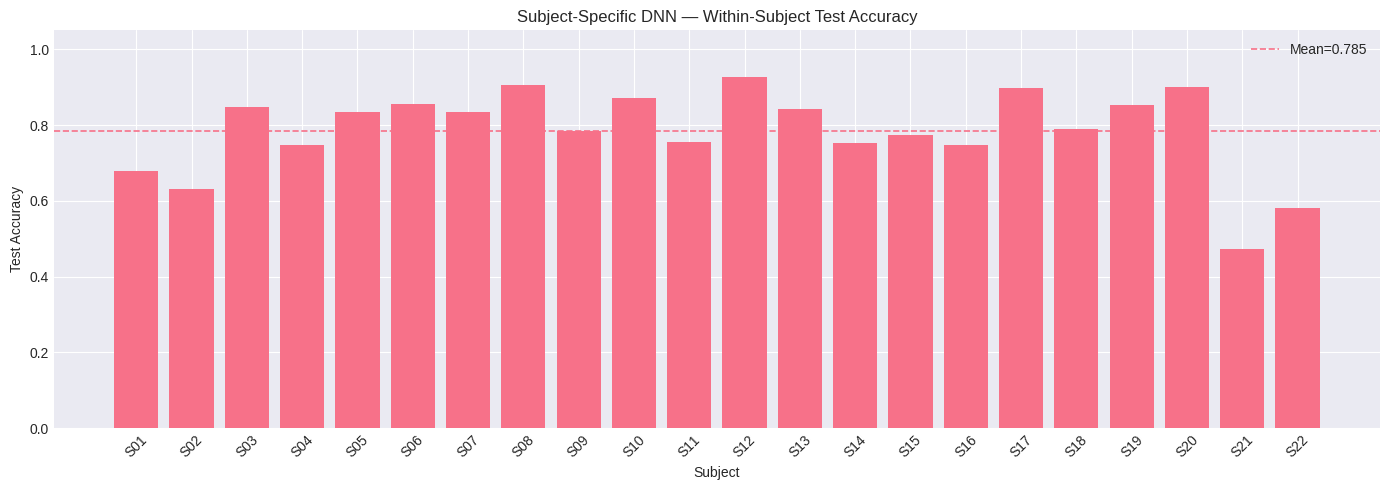

  Subject summary chart saved -> subject_specific_dnn_accuracy_summary.png

  FINAL SUBJECT-SPECIFIC WITHIN-SUBJECT DNN SUMMARY
 subject  accuracy  balanced_accuracy     f1_w  roc_auc_w  best_epoch
       1  0.677311           0.693996 0.669825   0.960132          16
       2  0.631043           0.673510 0.629375   0.946399          26
       3  0.847368           0.868975 0.841732   0.990509          29
       4  0.745946           0.771580 0.741992   0.973913          23
       5  0.835590           0.838451 0.834082   0.988960          59
       6  0.856419           0.855907 0.853296   0.984306          54
       7  0.835240           0.830142 0.829618   0.987578          37
       8  0.904762           0.909962 0.902289   0.995406          48
       9  0.783835           0.805153 0.781260   0.988790          41
      10  0.870079           0.875739 0.867777   0.992682          40
      11  0.754476           0.768269 0.753682   0.977709          26
      12  0.925856           0.9

In [15]:
assert len(Config.SUBJECTS) == 22
assert set(Config.SUBJECTS) == set(range(1, 23))
assert set(Config.RUN_SUBJECTS).issubset(
    set(Config.SUBJECTS)
)
assert Config.TRAIN_REPS == 4
assert Config.VAL_REPS == 1
assert Config.TEST_REPS == 1
assert (
    Config.TRAIN_REPS
    + Config.VAL_REPS
    + Config.TEST_REPS
    == Config.REPS_PER_GESTURE
)
assert Config.WIN_MS == 400
assert Config.STEP_MS == 100
assert Config.USE_ACC is True

print(
    'Running TRUE subject-specific within-subject '
    'DNN with strict leakage-safe EMG + ACC.'
)
print(
    f'Subject models: {Config.RUN_SUBJECTS}'
)
print(
    'For every subject/gesture: '
    '4 complete train repetitions + '
    '1 validation + 1 test repetition.'
)
print(
    'Safe order: split repetition -> filter EMG locally -> '
    'slice/resample ACC locally -> window -> features -> '
    'training-only scaling.'
)

(
    all_metrics,
    per_subject_results,
    aggregate_results,
    all_y_true,
    all_y_proba,
    repetition_assignments,
    repetition_provenance,
) = main_subject_specific_dnn()

print('\nExperiment complete.')
print(
    'Interpretation: subject-specific (subject-dependent) '
    'EMG+ACC DNN evaluated on unseen repetitions of the same person.'
)

In [16]:
print('\n' + '=' * 70)
print('  TRUE WITHIN-SUBJECT DNN EMG+ACC RESULT — ONE MODEL PER SUBJECT')
print('=' * 70)

print(
    per_subject_results[
        [
            'subject',
            'accuracy',
            'balanced_accuracy',
            'precision_w',
            'recall_w',
            'f1_w',
            'roc_auc_w',
        ]
    ].to_string(index=False)
)

print('\nAcross subject-specific DNN models:')
print(
    f'Mean Accuracy          : '
    f'{aggregate_results["mean_subject_accuracy"]:.4f} ± '
    f'{aggregate_results["std_subject_accuracy"]:.4f}'
)
print(
    f'Mean Balanced Accuracy : '
    f'{aggregate_results["mean_subject_balanced_accuracy"]:.4f} ± '
    f'{aggregate_results["std_subject_balanced_accuracy"]:.4f}'
)
print(
    f'Mean F1 (weighted)     : '
    f'{aggregate_results["mean_subject_f1_w"]:.4f} ± '
    f'{aggregate_results["std_subject_f1_w"]:.4f}'
)
print(
    f'Pooled Test Accuracy   : '
    f'{aggregate_results["pooled_test_accuracy"]:.4f}'
)

print(
    '\nReport this as: strict leakage-safe subject-specific within-subject EMG+ACC DNN evaluation. '
    'A separate DNN is trained for each DB7 subject using 4 training, '
    '1 validation, and 1 held-out test repetition per gesture.'
)


  TRUE WITHIN-SUBJECT DNN EMG+ACC RESULT — ONE MODEL PER SUBJECT
 subject  accuracy  balanced_accuracy  precision_w  recall_w     f1_w  roc_auc_w
       1  0.677311           0.693996     0.673472  0.677311 0.669825   0.960132
       2  0.631043           0.673510     0.648298  0.631043 0.629375   0.946399
       3  0.847368           0.868975     0.854558  0.847368 0.841732   0.990509
       4  0.745946           0.771580     0.751100  0.745946 0.741992   0.973913
       5  0.835590           0.838451     0.839272  0.835590 0.834082   0.988960
       6  0.856419           0.855907     0.874421  0.856419 0.853296   0.984306
       7  0.835240           0.830142     0.843978  0.835240 0.829618   0.987578
       8  0.904762           0.909962     0.909187  0.904762 0.902289   0.995406
       9  0.783835           0.805153     0.796094  0.783835 0.781260   0.988790
      10  0.870079           0.875739     0.880043  0.870079 0.867777   0.992682
      11  0.754476           0.768269     0